In [28]:
# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import random

In [12]:
# ================================================================
# 2. LOAD AND PREPROCESS DATA
# ================================================================
IMG_SIZE = 128
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE
num_classes = 10

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Load Fashion-MNIST
(x_train, y_train), (x_val, y_val) = fashion_mnist.load_data()

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Preprocessing
def preprocess(img, label):
    img = tf.image.resize(tf.expand_dims(img, -1), [IMG_SIZE, IMG_SIZE])
    img = tf.image.grayscale_to_rgb(img)
    img = img / 255.0
    return img, label

def preprocess_with_aug(img, label):
    img, label = preprocess(img, label)
    img = data_augmentation(img)
    return img, label

# Train dataset
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.map(preprocess_with_aug, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(2000).batch(batch_size).prefetch(AUTOTUNE)

# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val_cat))
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache().batch(batch_size).prefetch(AUTOTUNE)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
# ================================================================
# 2.5. CHECK DATA STRUCTURE
# ================================================================
print("\n--- Data Structure Check ---")

# Check the shape (rows and columns)
print(f"x_train shape (Training Images): {x_train.shape}")
print(f"y_train shape (Training Labels): {y_train.shape}")
print(f"x_val shape (Validation/Test Images): {x_val.shape}")

# Check the data type
print(f"Data type of images (x_train): {x_train.dtype}")
print(f"Data type of labels (y_train): {y_train.dtype}")

# Check the pixel value range (min and max)
print(f"Min pixel value (x_train): {np.min(x_train)}")
print(f"Max pixel value (x_train): {np.max(x_train)}")

# Check the label range to confirm 10 classes
print(f"Unique labels (y_train): {np.unique(y_train)}")
print("--- Check Complete ---")



--- Data Structure Check ---
x_train shape (Training Images): (60000, 28, 28)
y_train shape (Training Labels): (60000,)
x_val shape (Validation/Test Images): (10000, 28, 28)
Data type of images (x_train): uint8
Data type of labels (y_train): uint8
Min pixel value (x_train): 0
Max pixel value (x_train): 255
Unique labels (y_train): [0 1 2 3 4 5 6 7 8 9]
--- Check Complete ---


In [14]:
# ================================================================
# 3. BASELINE CNN (FOR COMPARISON)
# ================================================================

# A simple CNN architecture for Fashion-MNIST classification
baseline = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    Dense(128, activation="relu"),
    Dense(num_classes, activation="softmax")
])

# COMPILE MODEL
baseline.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n================= TRAINING BASELINE MODEL =================")
# Train for 5 epochs using prepared train/validation datasets
baseline.fit(train_ds, validation_data=val_ds, epochs=5)



================= TRAINING BASELINE MODEL =================
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.7276 - loss: 0.7502 - val_accuracy: 0.8141 - val_loss: 0.4992
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8445 - loss: 0.4184 - val_accuracy: 0.8427 - val_loss: 0.4408
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8861 - loss: 0.3065 - val_accuracy: 0.8543 - val_loss: 0.4547
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9239 - loss: 0.2083 - val_accuracy: 0.8508 - val_loss: 0.5337
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9513 - loss: 0.1329 - val_accuracy: 0.8429 - val_loss: 0.6879


In [15]:
# ================================================================
# 4. TRANSFER LEARNING MODEL (MobileNetV2)
# ================================================================

# Load the MobileNetV2 model pre-trained on ImageNet
base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu", kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

# Build the full model
model = Model(inputs=base.input, outputs=output)
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# ================================================================
# 5. CALLBACKS
# ================================================================
# Define callbacks to improve training stability and performance
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

In [17]:
# ================================================================
# 6. TRAIN TRANSFER LEARNING MODEL
# ================================================================
# Train the transfer learning model using the prepared datasets.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step - accuracy: 0.7237 - loss: 1.1025 - val_accuracy: 0.8492 - val_loss: 0.5983 - learning_rate: 5.0000e-04
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8171 - loss: 0.6632 - val_accuracy: 0.8528 - val_loss: 0.5411 - learning_rate: 5.0000e-04
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8268 - loss: 0.6090 - val_accuracy: 0.8557 - val_loss: 0.5053 - learning_rate: 5.0000e-04
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8269 - loss: 0.5863 - val_accuracy: 0.8614 - val_loss: 0.4854 - learning_rate: 5.0000e-04
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8326 - loss: 0.5723 - val_accuracy: 0.8648 - val_loss: 0.4732 - learning_rate: 5.0000e-04
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8317 - loss: 0.5629 - val_accuracy: 0.8579 - val_loss: 0.4830 - learning_rate: 5.0000e-04
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s

In [18]:
# ================================================================
# 7. FINE-TUNE LAST 20 LAYERS
# ================================================================

# Unfreeze the last 20 layers of MobileNetV2.
for layer in base.layers[-20:]:
    layer.trainable = True

# Recompile the model after changing trainable layers
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n================= FINE TUNING =================")
# Training for 10 epochs allows refinement while minimizing overfitting risk
model.fit(train_ds, validation_data=val_ds, epochs=10)


================= FINE TUNING =================
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - accuracy: 0.7917 - loss: 0.6509 - val_accuracy: 0.8792 - val_loss: 0.3921
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8564 - loss: 0.4566 - val_accuracy: 0.8887 - val_loss: 0.3699
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8728 - loss: 0.4085 - val_accuracy: 0.8907 - val_loss: 0.3575
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8814 - loss: 0.3789 - val_accuracy: 0.8933 - val_loss: 0.3500
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8923 - loss: 0.3532 - val_accuracy: 0.8945 - val_loss: 0.3431
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9012 - loss: 0.3274 - val_accuracy: 0.8958 - val_loss: 0.3372
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9051 - loss: 0.3120 - val_accuracy: 0.8987 - val_loss: 0.3359
Epoch 8/10
1875/1875 ━━━━━━━━━━━━

In [19]:
# ================================================================
# 7.5. FINAL EVALUATION
# ================================================================
print("\n================= FINAL MODEL EVALUATION =================")
loss, acc = model.evaluate(val_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")


================= FINAL MODEL EVALUATION =================
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8993 - loss: 0.3395
Test Loss: 0.3335
Test Accuracy: 0.9010


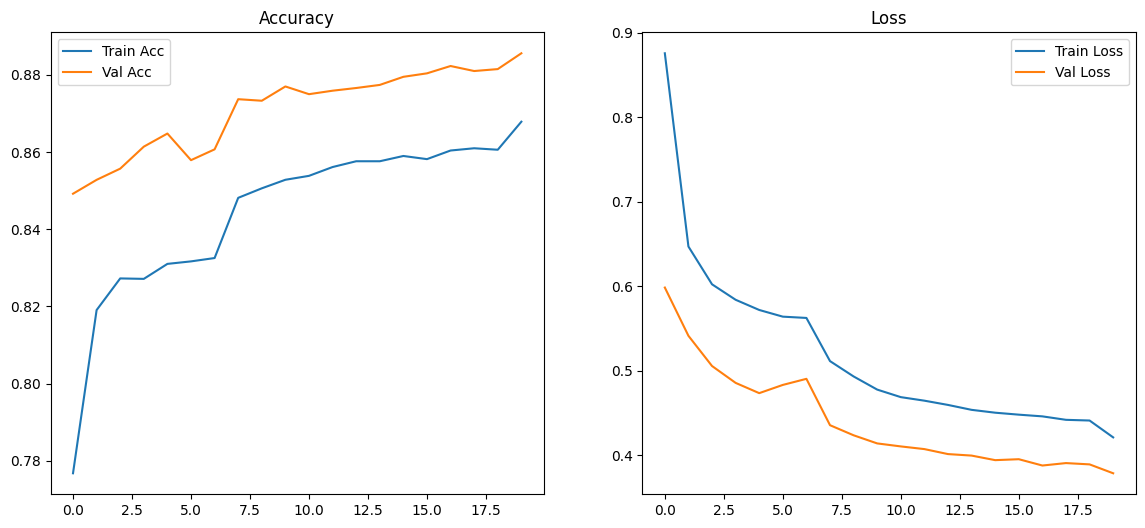

In [20]:
# ================================================================
# 8. TRAINING CURVES
# ================================================================
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step


<Figure size 1000x800 with 0 Axes>

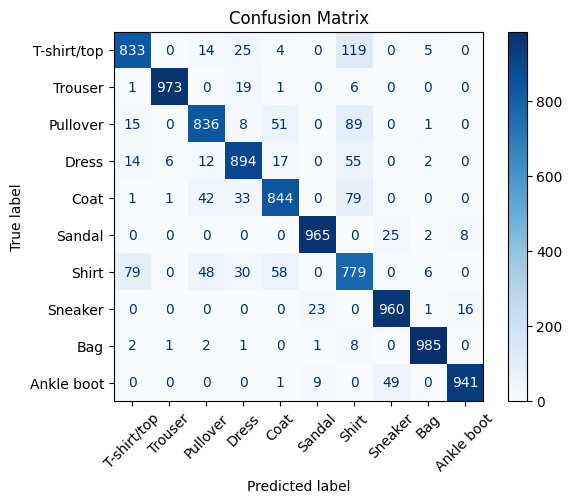

In [21]:
# ================================================================
# 9. CONFUSION MATRIX
# ================================================================

# Generate predictions for the entire validation dataset
# 'model.predict' outputs class probabilities for each class (10 classes)
y_pred = model.predict(val_ds)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val_cat, axis=1)

# Compute the confusion matrix comparing true vs. predicted labels.
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the confusion matrix using a heatmap for easier interpretation.
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [22]:
# ================================================================
# 10. CLASSIFICATION REPORT
# ================================================================
print("\n===== Classification Report =====")

# Generate precision, recall, F1-score, and support for each class
# Classification_report' summarizes model performance per class
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))


===== Classification Report =====
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.83      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.88      0.84      0.86      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.86      0.84      0.85      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.69      0.78      0.73      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



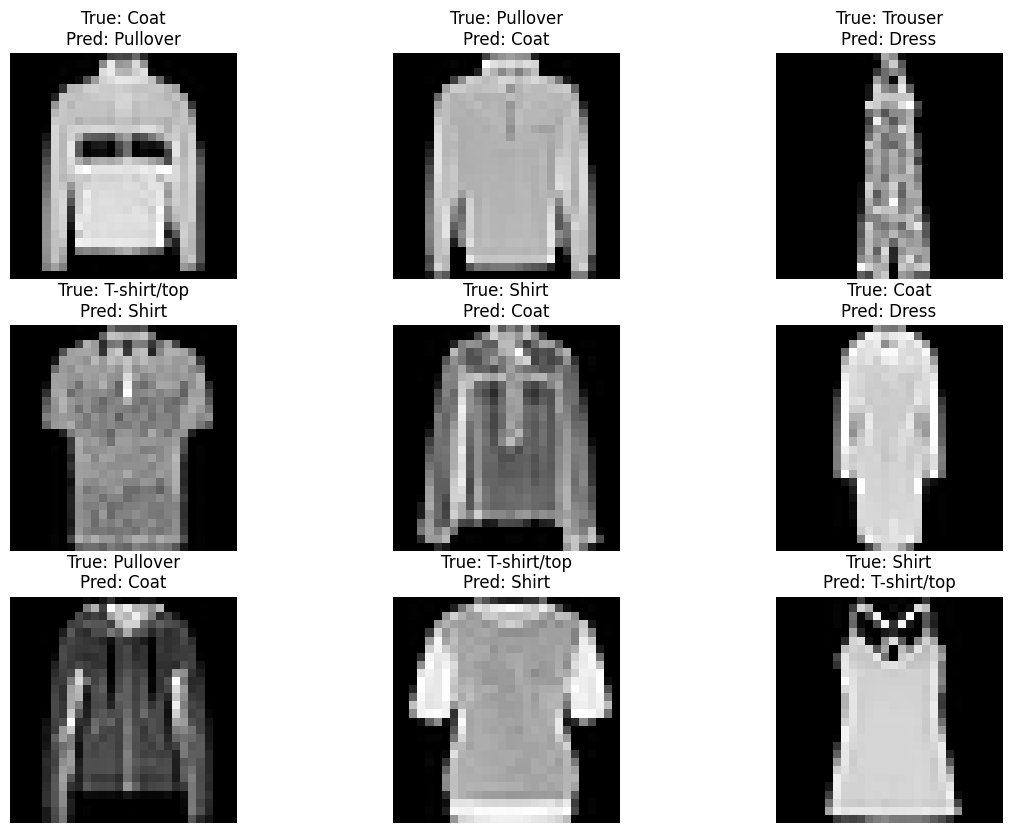

In [23]:
# ================================================================
# 11. SHOW MISCLASSIFIED IMAGES
# ================================================================

# Identify the indices where the model prediction does NOT match the true label
wrong_idx = np.where(y_pred_labels != y_true_labels)[0]

plt.figure(figsize=(14, 10))
for i, idx in enumerate(random.sample(list(wrong_idx), 9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_val[idx], cmap='gray')
    plt.title(f"True: {class_names[y_true_labels[idx]]}\nPred: {class_names[y_pred_labels[idx]]}")
    plt.axis('off')
plt.show()


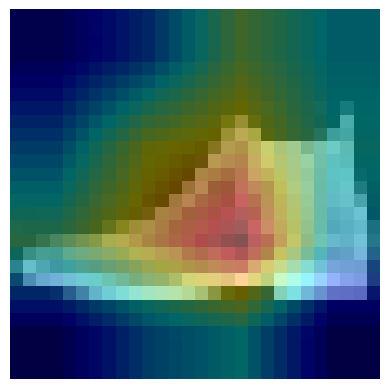

In [30]:
# ================================================================
# 12. GRAD-CAM EXPLAINABILITY
# ================================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Build a model that maps image -> (last conv layer outputs, predictions)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Gradient calculation
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    # Compute gradients
    grads = tape.gradient(loss, conv_output)

    # Global average pooling (importance of each channel)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight conv outputs
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize 0–1
    if tf.reduce_max(heatmap) != 0:
        heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()


# ------------------------------
# 2. Overlay heatmap on image
# ------------------------------
def show_gradcam(heatmap, image, alpha=0.4):
    # Resize heatmap to the image size
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

    # Apply colormap (BGR)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Ensure image is uint8 and 3-channel
    if image.max() <= 1:
        img_uint8 = np.uint8(image * 255)
    else:
        img_uint8 = np.uint8(image)

    # If grayscale → convert to RGB
    if len(img_uint8.shape) == 2 or img_uint8.shape[2] == 1:
        img_uint8 = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)

    # Convert heatmap BGR → RGB for correct display
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on original
    superimposed_img = cv2.addWeighted(img_uint8, 1 - alpha, heatmap, alpha, 0)

    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.show()

# ------------------------------
# 3. Generate Grad-CAM for one validation image
# ------------------------------
# Select one validation image
sample_img = x_val[0]

# Preprocess properly for the model input
input_img = tf.expand_dims(preprocess(sample_img, None)[0], 0)

# Use the last MobileNetV2 conv layer
LAST_CONV_LAYER = "out_relu"

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(input_img, model, LAST_CONV_LAYER)

# Show Grad-CAM overlay
show_gradcam(heatmap, sample_img)